In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Salary_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


Now that we have loaded the data, let's check its information and look for missing values and data types.

In [ ]:
# Get information about the DataFrame
display(df.info())

# Check for missing values
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


None

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
df = df.drop(columns=['Unnamed: 0'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


The dataset contains `YearsExperience` and `Salary` columns with no missing values. Both are numerical and suitable for linear regression. Now, let's visualize the relationship between `YearsExperience` and `Salary` using a scatter plot.

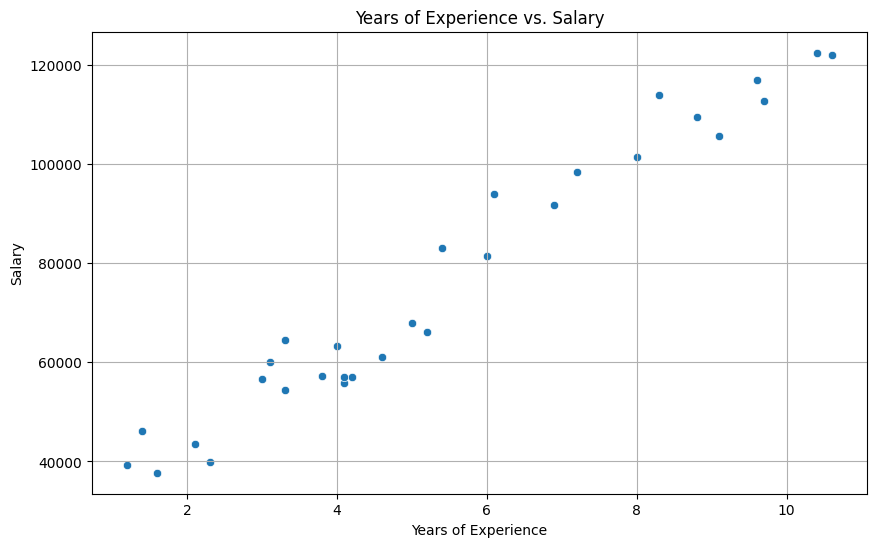

In [ ]:
# Visualize the relationship between YearsExperience and Salary
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title('Years of Experience vs. Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

The scatter plot suggests a clear linear relationship between `YearsExperience` and `Salary`. Now, let's prepare the data by splitting it into training and testing sets, then train a Linear Regression model.

In [ ]:
# Define features (X) and target (y)
X = df[['YearsExperience']]
y = df['Salary']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print(f"Model training complete. Intercept: {model.intercept_:.2f}, Coefficient: {model.coef_[0]:.2f}")

Model training complete. Intercept: 24380.20, Coefficient: 9423.82


The model has been trained. Now, let's make predictions on the test set and evaluate the model's performance using metrics like Mean Squared Error (MSE) and R-squared (R2).

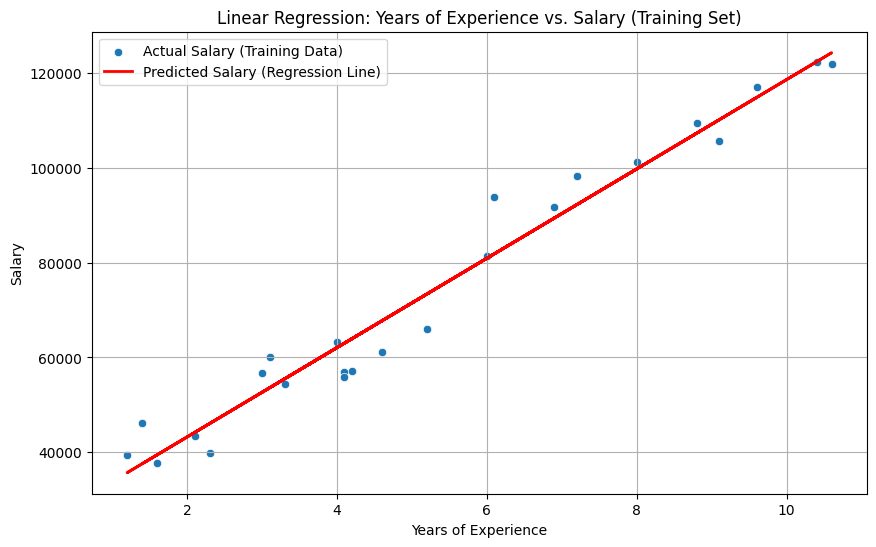

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['YearsExperience'], y=y_train, label='Actual Salary (Training Data)')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Predicted Salary (Regression Line)')
plt.title('Linear Regression: Years of Experience vs. Salary (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 49830096.86
R-squared (R2): 0.90


Finally, let's visualize the regression line along with the actual data points in the test set to see how well the model fits the data.

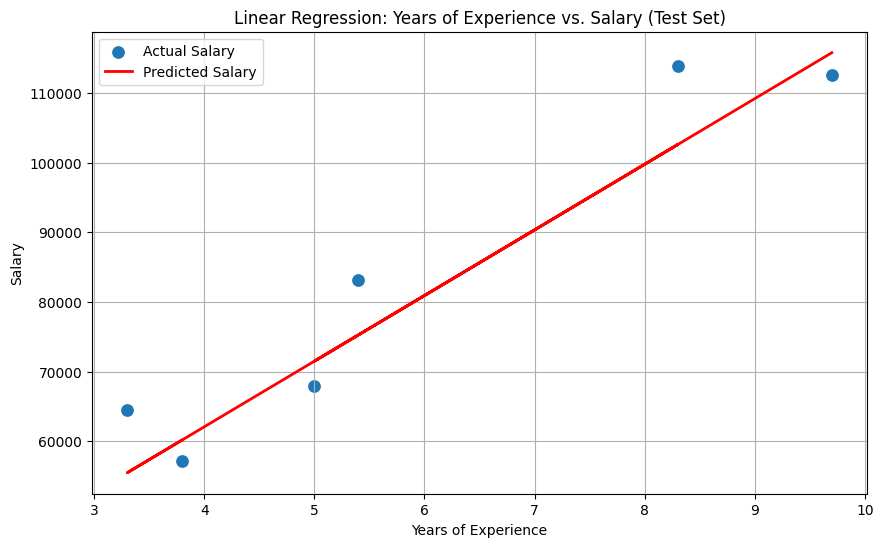

In [ ]:
# Plot the regression line with the test data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, label='Actual Salary', s=100)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Salary')
plt.title('Linear Regression: Years of Experience vs. Salary (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()